1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted value for x=2: 2.235086679458618
Exact value for x=2: 4
Error: 1.7649133205413818


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 10)                  │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 425 (1.66 KB)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 284 (1.11 KB)

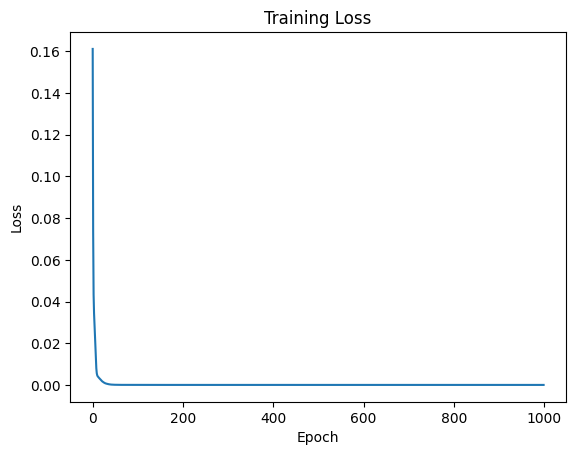

In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Generate dataset
x_train = np.linspace(0, 1, 1000)
y_train = x_train ** 2  # y = x^2

# Reshape for TensorFlow compatibility
x_train = x_train.reshape(-1, 1)
y_train = y_train.reshape(-1, 1)

# Define the neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1)  # Output layer
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(x_train, y_train, epochs=1000, verbose=0)

# Predict for x = 2
x_test = np.array([[2]])
y_pred = model.predict(x_test)

# Exact value
y_exact = x_test[0][0] ** 2

print(f"Predicted value for x=2: {y_pred[0][0]}")
print(f"Exact value for x=2: {y_exact}")
print(f"Error: {abs(y_pred[0][0] - y_exact)}")
model.summary()
# Plot training loss
plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()
